<p align="center">
  <img src="logo.png" styles="height:30px; width:auto" alt="iDetect logo" />
</p>

# iDetect — Machine Learning Pipeline

## Project overview

**Mission:** Reduce youth unemployment by supporting job creation.

**Problem:** The timing of investor and partner pitches strongly affects outcomes. **iDetect** estimates *approachability* from facial expressions so founders can choose a better moment to engage—aiming to improve funding success and, downstream, hiring.

**Dataset:** **AffectNet**-style layout: four emotion folders under one root.
- **Approachable (class 1):** `happy`, `neutral`
- **Not approachable (class 0):** `anger`, `contempt`

### Background

The **Introduction to Machine Learning** summative compared **classical ML**   with **deep learning** on the same iDetect task, reported seven DL experiments, and selected a winner by validation performance.
An early version of that work lives in the public repo [iDetect — Introduction summative](https://github.com/Bonaparte003/iDetect-Summative-introduction_to_machine_learning).


**Objective:** Turn that winning setup into a **single reproducible training run**

## Table of contents

1. **Setup** — installs, libraries, GPU memory, mixed precision  
2. **Paths** — Colab Drive (if used), `DATA_DIR`, `OUTPUT_DIR`, hyperparameters  
3. **Data** — load AffectNet folders; **balance** emotions and classes; stratified 60/20/20 split; `preprocess_input`  
4. **Input pipelines** — `tf.data` train / validation / test batches  
5. **Model** — EfficientNetB0: frozen-head phase → fine-tune last **30** backbone layers (intro notebook DL Exp 2)  
6. **Evaluation** — test-set metrics (accuracy, precision, recall, F1, ROC/AUC) and plots  
7. **Export** — `idetect_classifier.keras` and `metrics.json` for the repo / API

## 1. Install & imports


In [1]:
import gc
import json
import os
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
os.environ["PYTHONHASHSEED"] = "0"

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [2]:
gpus = tf.config.list_physical_devices("GPU")
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

if gpus:
    try:
        tf.keras.mixed_precision.set_global_policy("mixed_float16")
        print("Mixed precision ON")
    except Exception as e:
        print("Mixed precision skipped:", e)
else:
    print("No GPU detected — training will be slow.")

print("GPUs:", gpus)

Mixed precision ON
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Mount Drive & configuration

Point `DATA_DIR` at the folder that contains **`happy/`, `neutral/`, `anger/`, `contempt/`** (each folder holds images).  
`OUTPUT_DIR` is where weights and metrics will be written (e.g. a folder on Drive).

In [3]:
try:
    from google.colab import drive

    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("You're not in google colab, ensure to enter the proper paths on your localhost")


DATA_DIR = Path(
    "/content/drive/MyDrive/iDetect-Summative-introduction_to_machine_learning/AffectNet" if IN_COLAB else "./AffectNet"
)
OUTPUT_DIR = Path(
    "/content/drive/MyDrive/iDetect_outputs" if IN_COLAB else "./colab_out"
)

IMG_SIZE = 224
BATCH_SIZE = 32
LIMIT_PER_EMOTION = 220
EPOCHS_HEAD = 8
EPOCHS_FINETUNE = 12
UNFREEZE_LAST_N = 30
LR_HEAD = 1e-3
LR_FINETUNE = 1e-4

LABEL_MAP = {"happy": 1, "neutral": 1, "anger": 0, "contempt": 0}

(OUTPUT_DIR / "models").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "reports").mkdir(parents=True, exist_ok=True)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

Mounted at /content/drive
DATA_DIR: /content/drive/MyDrive/iDetect-Summative-introduction_to_machine_learning/AffectNet
OUTPUT_DIR: /content/drive/MyDrive/iDetect_outputs


## 3. Load images, equalize data, stratified split, EfficientNet preprocessing

- Read RGB, resize to `IMG_SIZE`, **uint8** in [0, 255].
- **Equal emotions:** for label **1**, `happy` and `neutral` contribute the **same** count; for label **0**, `anger` and `contempt` contribute the **same** count (each pair uses `min` of the two folder sizes after shuffle and optional `LIMIT_PER_EMOTION`).
- **Equal binary classes:** set **N** to the smaller of those two pair caps so each class has **2N** images total, then shuffle and apply stratified ** 60/ 20 / 20** train / val / test.
- Split **before** `preprocess_input` to avoid leakage; then **`preprocess_input`** per split (same as the intro notebook DL experiments).

In [4]:
def list_images(folder: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    if not folder.is_dir():
        return []
    return [p for p in folder.iterdir() if p.suffix.lower() in exts]


def load_emotion_lists(
    data_dir: Path,
    image_size: int,
    limit_per_emotion,
    seed: int,
) -> dict[str, list]:
    """Load decoded RGB uint8 images per emotion folder (shuffled, optionally capped)."""
    rng = np.random.default_rng(seed)
    out: dict[str, list] = {e: [] for e in LABEL_MAP}
    for emotion in LABEL_MAP:
        folder = data_dir / emotion
        files = list_images(folder)
        rng.shuffle(files)
        if limit_per_emotion is not None:
            files = files[:limit_per_emotion]
        for fp in tqdm(files, desc=emotion):
            bgr = cv2.imread(str(fp))
            if bgr is None:
                continue
            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            rgb = cv2.resize(rgb, (image_size, image_size))
            out[emotion].append(rgb.astype(np.uint8))
    return out


def build_equal_binary_dataset(
    data_dir: Path,
    image_size: int,
    limit_per_emotion,
    seed: int,
):
    """
    Equal data for approachable vs not approachable:
      - Same count from happy and neutral; same count from anger and contempt.
      - Then N = min(pair1_cap, pair0_cap) so each binary class has exactly 2*N images.
    """
    rng = np.random.default_rng(seed)
    s = load_emotion_lists(data_dir, image_size, limit_per_emotion, seed)
    n_h, n_n = len(s["happy"]), len(s["neutral"])
    n_a, n_c = len(s["anger"]), len(s["contempt"])
    pair1 = min(n_h, n_n)
    pair0 = min(n_a, n_c)
    if pair1 == 0 or pair0 == 0:
        raise RuntimeError(
            f"Need images in all four folders under {data_dir}. "
            f"Counts: happy={n_h} neutral={n_n} anger={n_a} contempt={n_c}"
        )
    N = min(pair1, pair0)
    imgs0 = s["anger"][:N] + s["contempt"][:N]
    imgs1 = s["happy"][:N] + s["neutral"][:N]
    X = np.stack(imgs0 + imgs1)
    y = np.asarray([0] * (2 * N) + [1] * (2 * N), dtype=np.int64)
    perm = rng.permutation(len(y))
    return X[perm], y[perm], N


X_uint8, y, N_per_emotion = build_equal_binary_dataset(
    DATA_DIR, IMG_SIZE, LIMIT_PER_EMOTION, SEED
)
print(
    "Dataset (equal 0/1; equal happy/neutral and anger/contempt):",
    dict(zip(*np.unique(y, return_counts=True))),
)
print(f"Images taken per emotion folder: N = {N_per_emotion}")

X_train_u8, X_temp_u8, y_train, y_temp = train_test_split(
    X_uint8, y, test_size=0.4, random_state=SEED, stratify=y
)
X_val_u8, X_test_u8, y_val, y_test = train_test_split(
    X_temp_u8, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

X_train = preprocess_input(np.copy(X_train_u8))
X_val = preprocess_input(np.copy(X_val_u8))
X_test = preprocess_input(np.copy(X_test_u8))

del X_uint8, X_train_u8, X_temp_u8, X_val_u8, X_test_u8
gc.collect()

print("train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)
print("class balance (train):", np.bincount(y_train))

happy:   0%|          | 0/220 [00:00<?, ?it/s]

neutral:   0%|          | 0/220 [00:00<?, ?it/s]

anger:   0%|          | 0/220 [00:00<?, ?it/s]

contempt:   0%|          | 0/220 [00:00<?, ?it/s]

Dataset (equal 0/1; equal happy/neutral and anger/contempt): {np.int64(0): np.int64(440), np.int64(1): np.int64(440)}
Images taken per emotion folder: N = 220
train: (528, 224, 224, 3) val: (176, 224, 224, 3) test: (176, 224, 224, 3)
class balance (train): [264 264]


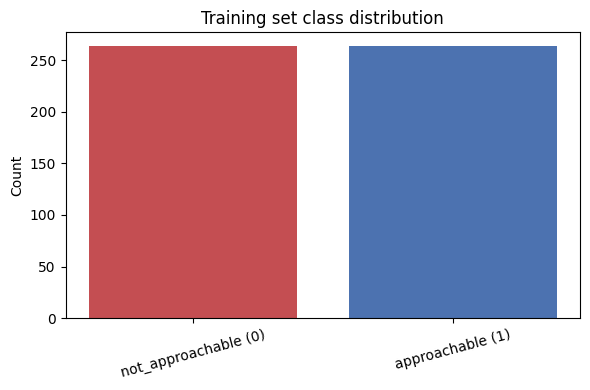

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
labels_txt = ["not_approachable (0)", "approachable (1)"]
counts = [np.sum(y_train == 0), np.sum(y_train == 1)]
ax.bar(labels_txt, counts, color=["#c44e52", "#4c72b0"])
ax.set_title("Training set class distribution")
ax.set_ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 4. `tf.data` input pipelines

In [6]:
AUTOTUNE = tf.data.AUTOTUNE


def make_ds(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(min(len(X), 4096), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = make_ds(X_train, y_train, shuffle=True)
val_ds = make_ds(X_val, y_val, shuffle=False)
test_ds = make_ds(X_test, y_test, shuffle=False)

## 5. Model — best deep-learning experiment from the intro summative

This matches **`notebook/iDetect_Project_Summative_introduction_to_machine_learning-2.ipynb`**: **EfficientNetB0 (Fine-tuned)** — **DL Experiment 2** (best among the seven DL runs by validation AUC), i.e. frozen-head training then partial unfreezing of the backbone.

**Phase A (DL Exp 1):** Entire backbone frozen, `base(..., training=False)`, train **GAP → Dense(128, relu) → Dropout → Dense(1, sigmoid)** with `LR_HEAD`.

**Phase B (DL Exp 2):** Freeze **`base.layers[:-UNFREEZE_LAST_N]`** (default **top 30** trainable layers), `base(..., training=True)`, `LR_FINETUNE`.

Use **`dtype=float32`** on dense layers so mixed precision stays stable.

In [7]:
def build_model(unfreeze_last_n: int = 0):
    base = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    if unfreeze_last_n <= 0:
        base.trainable = False
    else:
        base.trainable = True
        for layer in base.layers[:-unfreeze_last_n]:
            layer.trainable = False
        for layer in base.layers[-unfreeze_last_n:]:
            layer.trainable = True

    base_training = unfreeze_last_n > 0
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inp, training=base_training)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu", dtype="float32")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    return tf.keras.Model(inp, out, name="efficientnet_binary")


def compile_model(m, lr: float):
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )


ckpt = str(OUTPUT_DIR / "models" / "idetect_classifier.keras")
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=4, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        ckpt, monitor="val_auc", mode="max", save_best_only=True, verbose=1
    ),
]

In [8]:
### Phase A — head only (base fully frozen)
model = build_model(unfreeze_last_n=0)
compile_model(model, LR_HEAD)
model.summary()

hist_a = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks,
    verbose=1,
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "efficientnet_binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7286 - auc: 0.7953 - loss: 0.5537 - precision: 0.7708 - recall: 0.6392  
Epoch 1: val_auc improved from None to 0.94105, saving model to /content/drive/MyDrive/iDetect_outputs/models/idetect_classifier.keras

Epoch 1: finished saving model to /content/drive/MyDrive/iDetect_outputs/models/idetect_classifier.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 149s 5s/step - accuracy: 0.7727 - auc: 0.8469 - loss: 0.4995 - precision: 0.7903 - recall: 0.7424 - val_accuracy: 0.8693 - val_auc: 0.9411 - val_loss: 0.3411 - val_precision: 0.8916 - val_recall: 0.8409 - learning_rate: 0.0010
Epoch 2/8
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8566 - auc: 0.9538 - loss: 0.3045 - precision: 0.8872 - recall: 0.8290
Epoch 2: val_auc improved from 0.94105 to 0.96384, saving model to /content/drive/MyDrive/iDetect_outputs/models/idetect_classifier.keras

Epoch 2: finished saving model to /content/drive/MyDrive/iDetect_outputs/models/idetect_classifi

In [9]:
### Phase B — fine-tune top N backbone layers (intro notebook: 30)
n_layers = len(model.layers[1].layers)
print(f"Backbone has {n_layers} layers; training top {UNFREEZE_LAST_N} (frozen bottom {n_layers - UNFREEZE_LAST_N})")

model = build_model(unfreeze_last_n=UNFREEZE_LAST_N)
# Warm-start weights from phase A (same architecture)
wts = tf.keras.models.load_model(ckpt, compile=False).get_weights()
model.set_weights(wts)

compile_model(model, LR_FINETUNE)
trainable = sum(int(l.trainable) for l in model.layers[1].layers)
print(f"Trainable backbone layers: {trainable}")

hist_b = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINETUNE,
    callbacks=callbacks,
    verbose=1,
)

Backbone has 238 layers; training top 30 (frozen bottom 208)
Trainable backbone layers: 30
Epoch 1/12
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8798 - auc: 0.9441 - loss: 0.3254 - precision: 0.8679 - recall: 0.9139  
Epoch 1: val_auc did not improve from 0.98308
17/17 ━━━━━━━━━━━━━━━━━━━━ 141s 5s/step - accuracy: 0.8883 - auc: 0.9509 - loss: 0.3044 - precision: 0.8674 - recall: 0.9167 - val_accuracy: 0.9034 - val_auc: 0.9751 - val_loss: 0.2243 - val_precision: 0.8586 - val_recall: 0.9659 - learning_rate: 1.0000e-04
Epoch 2/12
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9610 - auc: 0.9941 - loss: 0.1531 - precision: 0.9528 - recall: 0.9672
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 2: val_auc did not improve from 0.98308
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9564 - auc: 0.9939 - loss: 0.1519 - precision: 0.9547 - recall: 0.9583 - val_accuracy: 0.9205 - val_auc: 0.9797 - val_loss: 0.1833 - val_precision: 0.9022 -

## 6. Test-set evaluation

In [10]:
best = tf.keras.models.load_model(ckpt, compile=False)
y_prob = best.predict(test_ds, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(np.int64)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
try:
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
except ValueError as e:
    print("ROC-AUC:", e)
print(classification_report(y_test, y_pred, target_names=["not_app", "app"]))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9488636363636364
Precision: 0.9540229885057471
Recall: 0.9431818181818182
F1: 0.9485714285714286
ROC-AUC: 0.9868285123966942
              precision    recall  f1-score   support

     not_app       0.94      0.95      0.95        88
         app       0.95      0.94      0.95        88

    accuracy                           0.95       176
   macro avg       0.95      0.95      0.95       176
weighted avg       0.95      0.95      0.95       176

Confusion matrix:
 [[84  4]
 [ 5 83]]


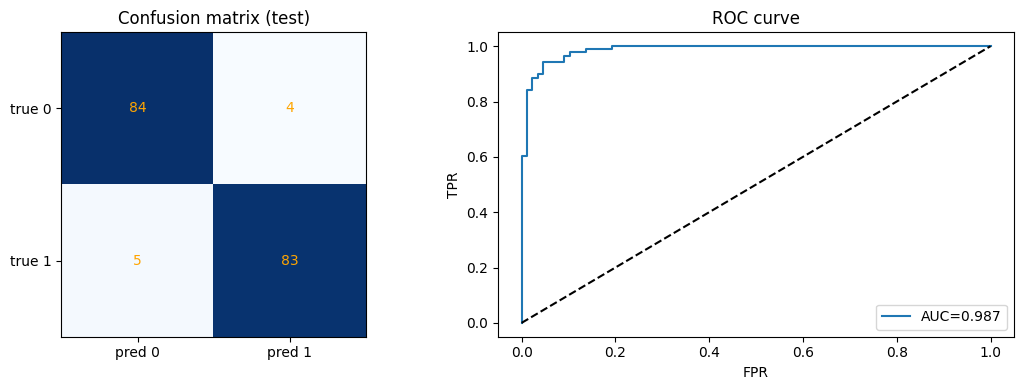

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm = confusion_matrix(y_test, y_pred)
axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["pred 0", "pred 1"])
axes[0].set_yticklabels(["true 0", "true 1"])
axes[0].set_title("Confusion matrix (test)")
for (i, j), v in np.ndenumerate(cm):
    axes[0].text(j, i, int(v), ha="center", va="center", color="orange")

try:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, y_prob):.3f}")
    axes[1].plot([0, 1], [0, 1], "k--")
    axes[1].set_xlabel("FPR")
    axes[1].set_ylabel("TPR")
    axes[1].set_title("ROC curve")
    axes[1].legend()
except Exception as e:
    axes[1].set_title(f"ROC unavailable: {e}")

plt.tight_layout()
plt.show()

## 7. Export for the repo (API / local retrain)

- **`idetect_classifier.keras`** — copy to `Summative-assignment---MLOP/models/idetect_classifier.keras`.  
- **`metrics.json`** — `Summative-assignment---MLOP/reports/metrics.json`

Local retraining (same preprocessing + head in `src/`):  
`python -m src.train --data_dir AffectNet --output_dir . --unfreeze_last_n 30`

In [ ]:
try:
    _roc = float(roc_auc_score(y_test, y_prob))
except ValueError:
    _roc = None

metrics_payload = {
    "notebook": "colab_efficientnet_intro_recipe",
    "img_size": IMG_SIZE,
    "unfreeze_last_n": UNFREEZE_LAST_N,
    "epochs_head": EPOCHS_HEAD,
    "epochs_finetune": EPOCHS_FINETUNE,
    "test_metrics": {
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "precision": float(precision_score(y_test, y_pred, zero_division=0)),
        "recall": float(recall_score(y_test, y_pred, zero_division=0)),
        "f1": float(f1_score(y_test, y_pred, zero_division=0)),
        "roc_auc": _roc,
        "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
        "classification_report": classification_report(
            y_test, y_pred, zero_division=0
        ),
    },
    "model_path": ckpt,
}

meta_path = OUTPUT_DIR / "reports" / "metrics.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)

print("Saved:", ckpt)
print("Saved:", meta_path)

if IN_COLAB:
    from google.colab import files

    print("Download idetect_classifier.keras from the Files pane or:")

Saved: /content/drive/MyDrive/iDetect_outputs/models/idetect_classifier.keras
Saved: /content/drive/MyDrive/iDetect_outputs/reports/metrics.json
Download idetect_classifier.keras from the Files pane or:
